# Fig 2 v1 — aparc vs hammers insula brain preview

Uses **two** packaged HGA trees from `package_HGA.py --atlas`:

- aparc: `../results/{task}(bipolar)(aparc2009s)/`
- hammers: `../results/{task}(bipolar)(hammers)/`

Produces insula panels (LH / RH each):

1. **aparc** — Destrieux gross Insula; AIC/PIC via Y + label.
2. **hammers** — pure `AIC` / `PIC` electrodes only (excludes mixed labels).
3. **hammers (6 gyri)** — Hammers insula gyri from `label` (separate block below).

Set `phase` in the config cell (`stimulus`, `delay`, `go`, `response`).


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import mne
from mne_bids import BIDSPath
from tqdm import tqdm
from pathlib import Path


def insula_mask(df, atlas):
    """Boolean mask for insula electrodes (aparc: INS/Insula; hammers: pure AIC/PIC)."""
    if atlas in ('aparc', 'aparc2009s'):
        return df['roi'].isin({'INS', 'Insula'})
    mask = df['roi'].isin({'AIC', 'PIC'})
    if 'mix' in df.columns:
        mask = mask & ~df['mix'].fillna(False).astype(bool)
    return mask


In [18]:
cm = 1 / 2.54
plt.rcParams['svg.fonttype'] = 'none'
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)
insula_cmap = sns.light_palette(insula_color, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')

# --- manual plot controls ---
phase = 'stimulus'  # stimulus | delay | go | response


## Load significant HGA


In [19]:
task = [
    'PhonemeSequencing',
    'LexicalDelay',
]

ref = 'bipolar'


def load_packaged_hga(task_name, atlas='aparc2009s'):
  root = f'../results/{task_name}(bipolar)({atlas})'
  paths = BIDSPath(
      root=root,
      datatype='HGA',
      suffix='time',
      check=False,
  ).match()
  if not paths:
      print(f'Warning: no HGA files under {root}')
      return pd.DataFrame()
  frames = [pd.read_csv(path) for path in tqdm(paths, desc=f'load {task_name}({atlas})')]
  return pd.concat(frames, ignore_index=True)


HGAs_aparc = pd.concat([load_packaged_hga(t, 'aparc2009s') for t in task], ignore_index=True)
HGAs_hammers = pd.concat([load_packaged_hga(t, 'hammers') for t in task], ignore_index=True)

for df in (HGAs_aparc, HGAs_hammers):
    if not df.empty:
        df['phase'] = df['phase'].str.lower()

print(f'aparc rows: {len(HGAs_aparc):,} | hammers rows: {len(HGAs_hammers):,}')
HGAs_aparc.head()


load LexicalDelay(hammers): 100%|██████████| 392/392 [00:08<00:00, 47.14it/s]


aparc rows: 4,678,400 | hammers rows: 4,605,120


,time,channel,value,mask,subject,description,task,phase,modality,label,...,y1_template,z1_template,x2_template,y2_template,z2_template,contact_1,contact_2,contact_1_label,contact_2_label,mix
0,-1.000000,D0019_RLOS2-3,-0.050144,False,D0019,Repeat,PhonemeSequencing,delay,sound,ctx_rh_G_pariet_inf-Angular,...,-35.1426,37.1628,51.1196,-26.6596,38.1841,RLOS2,RLOS3,Unknown,Unknown,False
1,-0.992188,D0019_RLOS2-3,-0.096867,False,D0019,Repeat,PhonemeSequencing,delay,sound,ctx_rh_G_pariet_inf-Angular,...,-35.1426,37.1628,51.1196,-26.6596,38.1841,RLOS2,RLOS3,Unknown,Unknown,False
2,-0.984375,D0019_RLOS2-3,-0.125324,False,D0019,Repeat,PhonemeSequencing,delay,sound,ctx_rh_G_pariet_inf-Angular,...,-35.1426,37.1628,51.1196,-26.6596,38.1841,RLOS2,RLOS3,Unknown,Unknown,False
3,-0.976562,D0019_RLOS2-3,-0.123982,False,D0019,Repeat,PhonemeSequencing,delay,sound,ctx_rh_G_pariet_inf-Angular,...,-35.1426,37.1628,51.1196,-26.6596,38.1841,RLOS2,RLOS3,Unknown,Unknown,False
4,-0.968750,D0019_RLOS2-3,-0.100060,False,D0019,Repeat,PhonemeSequencing,delay,sound,ctx_rh_G_pariet_inf-Angular,...,-35.1426,37.1628,51.1196,-26.6596,38.1841,RLOS2,RLOS3,Unknown,Unknown,False


In [20]:
# fpath = '../results/exlude_insula.csv'
# exclude_df = pd.read_csv(fpath, index_col=0)
# exclude_chn = [
#     electrode
#     for item in exclude_df.Exclude.dropna()
#     for electrode in eval(item)
# ]

# HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
# print(f'Excluded {len(exclude_chn)} channels')


## Insula channel counts (aparc vs hammers)


In [21]:
display_cols = ['subject', 'channel', 'label', 'roi', 'hemi', 'mix']

for name, hgas, atlas in [
    ('aparc', HGAs_aparc, 'aparc'),
    ('hammers', HGAs_hammers, 'hammers'),
]:
    if hgas.empty:
        print(f'{name}: no data loaded')
        continue
    channels = (
        hgas.loc[insula_mask(hgas, atlas)]
        .drop_duplicates('channel')
        .sort_values(['subject', 'channel'])
    )
    print(f'{name} insula channels: {len(channels)}')
    show_cols = [c for c in display_cols if c in channels.columns]
    display(channels[show_cols].head(10))

if not HGAs_aparc.empty and not HGAs_hammers.empty:
    ch_aparc = set(HGAs_aparc.loc[insula_mask(HGAs_aparc, 'aparc'), 'channel'].unique())
    ch_hammers = set(HGAs_hammers.loc[insula_mask(HGAs_hammers, 'hammers'), 'channel'].unique())
    print(
        f'overlap: {len(ch_aparc & ch_hammers)} | '
        f'aparc-only: {len(ch_aparc - ch_hammers)} | '
        f'hammers-only: {len(ch_hammers - ch_aparc)}'
    )


aparc insula channels: 369


,subject,channel,label,roi,hemi,mix
5440,D0022,D0022_LPIF4-5,ctx_lh_S_circular_insula_inf,INS,L,False
1319698,D0023,D0023_R2IF1-2,ctx_rh_S_circular_insula_sup,INS,R,False
1327073,D0023,D0023_R2IF2-3,ctx_rh_S_circular_insula_sup,INS,R,False
1396484,D0027,D0027_LAI3-4,ctx_lh_S_circular_insula_sup,INS,L,False
1411531,D0027,D0027_LPI1-2,Left-Cerebral-White-Matter,INS,L,False
32977,D0028,D0028_LAI1-2,ctx_lh_G_insular_short,INS,L,False
32976,D0028,D0028_LAI2-3,Left-Cerebral-White-Matter,INS,L,False
32965,D0028,D0028_LAI3-4,ctx_lh_G_insular_short,INS,L,False
32960,D0028,D0028_LPI2-3,ctx_lh_G_Ins_lg_and_S_cent_ins,INS,L,False
32967,D0028,D0028_LPI4-5,Left-Cerebral-White-Matter,INS,L,False


hammers insula channels: 212


,subject,channel,label,roi,hemi,mix
1299538,D0023,D0023_R2IF1-2,insula anterior long gyrus R,PIC,R,False
32977,D0028,D0028_LAI1-2,insula anterior pole L,AIC,L,False
32976,D0028,D0028_LAI2-3,0,AIC,L,False
32965,D0028,D0028_LAI3-4,insula anterior short gyrus L,AIC,L,False
32967,D0028,D0028_LPI4-5,0,AIC,L,False
1527693,D0032,D0032_LAI2-3,insula middle short gyrus L,AIC,L,False
1512324,D0032,D0032_LAI3-4,insula middle short gyrus L,AIC,L,False
1522252,D0032,D0032_LPI3-4,insula posterior long gyrus L,PIC,L,False
1516482,D0032,D0032_LPI6-7,insula posterior short gyrus L,AIC,L,False
1565767,D0035,D0035_LAI2-3,insula anterior pole L,AIC,L,False


overlap: 197 | aparc-only: 172 | hammers-only: 15


## Build spatial tables + brain scatter

After changing `phase` in the config cell, re-run from the spatial-prep cell below.


In [22]:
# Uses `phase` from the config cell above.

exclude_channels = set(globals().get('exclude_chn', []))

SPATIAL_AGG = {
    'value': 'mean',
    'x': 'first', 'y': 'first', 'z': 'first',
    'roi': 'first', 'label': 'first', 'hemi': 'first',
    'subject': 'first', 'description': 'first', 'task': 'first', 'phase': 'first',
}
if 'mix' in HGAs_aparc.columns:
    SPATIAL_AGG['mix'] = 'first'


def build_spatial(hgas, atlas, phase_name, exclude_chn=None):
    """One row per channel: mean HGA in phase window for atlas-filtered electrodes."""
    exclude_chn = exclude_chn or set()
    atlas_df = hgas.loc[insula_mask(hgas, atlas)].copy()
    task_subset = atlas_df[
        (atlas_df.description == 'Repeat')
        & (atlas_df.modality == 'sound')
        & (atlas_df.subject != 'D0121')
    ]
    exclude_subset = task_subset[~task_subset.channel.isin(exclude_chn)]
    phase_subset = exclude_subset[
        (exclude_subset.phase == phase_name)
        & (exclude_subset.time > 0)
        & (exclude_subset.time < 0.5)
    ]
    if phase_subset.empty:
        return phase_subset.assign(HGA=pd.Series(dtype=float))
    spatial_df = (
        phase_subset.groupby('channel')
        .agg({k: v for k, v in SPATIAL_AGG.items() if k in phase_subset.columns})
        .reset_index()
    )
    spatial_df.rename(columns={'value': 'HGA'}, inplace=True)
    return spatial_df


spatial_aparc = build_spatial(HGAs_aparc, 'aparc', phase, exclude_channels)
spatial_hammers = build_spatial(HGAs_hammers, 'hammers', phase, exclude_channels)

print(f"phase={phase!r}")
print(f'aparc electrodes in spatial plot: {len(spatial_aparc)}')
print(f'hammers electrodes in spatial plot: {len(spatial_hammers)}')
spatial_aparc.head()


phase='stimulus'
aparc electrodes in spatial plot: 164
hammers electrodes in spatial plot: 83


,channel,HGA,x,y,z,roi,label,hemi,subject,description,task,phase,mix
0,D0023_R2IF1-2,0.133529,35.7033,7.35276,-0.94740,INS,ctx_rh_S_circular_insula_sup,R,D0023,Repeat,LexicalDelay,stimulus,False
1,D0027_LAI3-4,0.069447,-29.3719,31.56180,-8.52550,INS,ctx_lh_S_circular_insula_sup,L,D0027,Repeat,LexicalDelay,stimulus,False
2,D0027_LPI1-2,0.099485,-33.7990,11.83384,-14.99816,INS,Left-Cerebral-White-Matter,L,D0027,Repeat,LexicalDelay,stimulus,False
3,D0028_LAI2-3,0.106650,-32.9578,31.56930,-24.46664,INS,Left-Cerebral-White-Matter,L,D0028,Repeat,PhonemeSequencing,stimulus,False
4,D0035_LPI6-7,0.117743,-34.9692,8.40797,-3.98950,INS,ctx_lh_S_circular_insula_sup,L,D0035,Repeat,PhonemeSequencing,stimulus,False


Reading labels from parcellation...
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/lh.aparc.a2009s.annot
   read 75 labels from /cwork/ns458/ECoG_Recon/cvs_avg35_inMNI152/label/rh.aparc.a2009s.annot
Skip plot (no AIC/PIC electrodes): Perception HGA — aparc


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-12 13:14:28.730 (2355.747s) [    7F61A8D70740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x210993f0): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/car

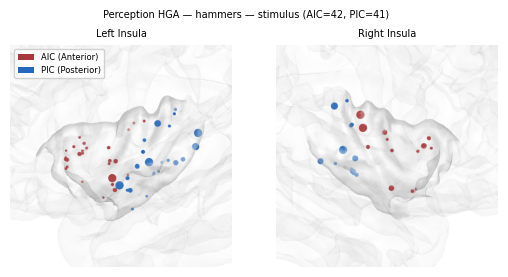

In [23]:
import pyvista as pv
from mne.viz import Brain
from scipy.spatial import cKDTree
from matplotlib.patches import Patch

INSULA_PATTERNS = [
    'G_insular_short', 'G_Ins_lg_and_S_cent_ins',
    'S_circular_insula_ant', 'S_circular_insula_inf', 'S_circular_insula_sup',
]

labels = mne.read_labels_from_annot(
    subject='cvs_avg35_inMNI152', parc='aparc.a2009s',
    surf_name='pial', hemi='both', subjects_dir=recon_dir,
)
lh_pial_coords, _ = mne.read_surface(f'{recon_dir}/cvs_avg35_inMNI152/surf/lh.pial')
rh_pial_coords, _ = mne.read_surface(f'{recon_dir}/cvs_avg35_inMNI152/surf/rh.pial')
lh_tree = cKDTree(lh_pial_coords)
rh_tree = cKDTree(rh_pial_coords)


def _insula_center(hemi, pial_coords):
    vertices = []
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in INSULA_PATTERNS):
            vertices.extend(lab.vertices)
    return pial_coords[vertices].mean(axis=0) if vertices else None


lh_center = _insula_center('lh', lh_pial_coords)
rh_center = _insula_center('rh', rh_pial_coords)


def _make_insula_brain(hemi):
    brain = Brain(
        'cvs_avg35_inMNI152', subjects_dir=recon_dir, surf='pial',
        hemi=hemi, background='white', show=False,
        cortex=(0.9, 0.9, 0.9), alpha=0.05, size=(800, 800),
    )
    for lab in labels:
        if lab.hemi == hemi and any(p in lab.name for p in INSULA_PATTERNS):
            brain.add_label(lab, borders=False, color=(0.9, 0.9, 0.9), alpha=0.6)
    return brain


ROI_COLORS = {'AIC': red, 'PIC': blue}


def classify_insula_row(row, y_threshold=0):
    """Classify aparc Insula electrodes into AIC or PIC (fig2.ipynb)."""
    if row.get('roi') != 'Insula':
        return row.get('roi')
    label = row['label']
    y_coord = row['y']
    if ('G_insular_short' in label or
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    if ('G_Ins_lg_and_S_cent_ins' in label or
        ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
        ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    return row.get('roi')


def attach_sub_roi(spatial_df, atlas):
    """Add sub_roi: aparc via Destrieux+y; hammers via pure AIC/PIC roi."""
    out = spatial_df.copy()
    if atlas in ('aparc', 'aparc2009s'):
        out['sub_roi'] = out.apply(classify_insula_row, axis=1, y_threshold=0)
    else:
        out['sub_roi'] = out['roi'].where(out['roi'].isin(['AIC', 'PIC']))
    return out


def _hga_to_size(hga_values, size_min=8, size_max=30):
    vmin = 0
    vmax = np.percentile(hga_values, 95) if len(hga_values) else 1
    if not np.isfinite(vmax) or vmax <= vmin:
        vmax = vmin + 1
    normalized = np.clip((hga_values - vmin) / (vmax - vmin), 0, 1)
    return size_min + normalized * (size_max - size_min), vmin, vmax


def _add_electrodes(brain, coords, hga_vals, roi_vals, tree, pial_coords):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    sizes, _, _ = _hga_to_size(hga_vals)
    for i, pt in enumerate(coords_proj):
        color = ROI_COLORS.get(roi_vals[i])
        if color is None:
            continue
        cloud = pv.PolyData(pt.reshape(1, 3))
        brain._renderer.plotter.add_mesh(
            cloud, render_points_as_spheres=True,
            point_size=sizes[i], color=color, lighting=False,
        )


def plot_insula_spatial(spatial_df, *, title, save_path=None):
    """Top-down LH/RH insula panel with AIC (red) vs PIC (blue)."""
    plot_df = spatial_df[spatial_df['sub_roi'].isin(['AIC', 'PIC'])].copy()
    if plot_df.empty:
        print(f'Skip plot (no AIC/PIC electrodes): {title}')
        return
    n_skip = len(spatial_df) - len(plot_df)
    if n_skip:
        print(f'{title}: skipping {n_skip} unclassified / mixed electrodes')
    cord = plot_df[['x', 'y', 'z']].values
    hga_values = plot_df['HGA'].values
    roi_values = plot_df['sub_roi'].values
    mask_lh = cord[:, 0] < 0
    mask_rh = cord[:, 0] > 0

    lh_brain = _make_insula_brain('lh')
    rh_brain = _make_insula_brain('rh')
    if mask_lh.any():
        _add_electrodes(
            lh_brain, cord[mask_lh], hga_values[mask_lh], roi_values[mask_lh],
            lh_tree, lh_pial_coords,
        )
    if mask_rh.any():
        _add_electrodes(
            rh_brain, cord[mask_rh], hga_values[mask_rh], roi_values[mask_rh],
            rh_tree, rh_pial_coords,
        )

    lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_center)
    rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_center)

    fig, axes = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm))
    axes[0].imshow(lh_brain.screenshot(mode='rgb'))
    axes[0].axis('off')
    axes[0].set_title('Left Insula', fontsize=fontsize)
    axes[1].imshow(rh_brain.screenshot(mode='rgb'))
    axes[1].axis('off')
    axes[1].set_title('Right Insula', fontsize=fontsize)
    axes[0].legend(
        handles=[
            Patch(facecolor=red, label='AIC (Anterior)'),
            Patch(facecolor=blue, label='PIC (Posterior)'),
        ],
        loc='upper left', fontsize=fontsize - 1, framealpha=0.9,
    )
    n_aic = (plot_df['sub_roi'] == 'AIC').sum()
    n_pic = (plot_df['sub_roi'] == 'PIC').sum()
    plt.suptitle(
        f'{title} — {phase} (AIC={n_aic}, PIC={n_pic})',
        fontsize=fontsize,
    )
    lh_brain.close()
    rh_brain.close()
    plt.subplots_adjust(bottom=0.15)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


spatial_aparc = attach_sub_roi(spatial_aparc, 'aparc')
spatial_hammers = attach_sub_roi(spatial_hammers, 'hammers')

plot_insula_spatial(
    spatial_aparc,
    title='Perception HGA — aparc',
    # save_path=f'../img/fig2/fig2v1_insula_spatial_aparc_{phase}.svg',
)

plot_insula_spatial(
    spatial_hammers,
    title='Perception HGA — hammers',
    # save_path=f'../img/fig2/fig2v1_insula_spatial_hammers_{phase}.svg',
)


## Hammers — 6 insula gyri (spatial)

Uses Hammers `label` strings (`insula anterior pole L`, etc.) to color electrodes by the six insular gyri. Re-run after changing `phase` in the config cell (requires `spatial_hammers` from above).


Hammers gyrus counts (spatial window):
hammers_gyrus
anterior pole             6
anterior short gyrus     18
middle short gyrus        2
anterior long gyrus      14
posterior short gyrus    10
posterior long gyrus     19
Name: count, dtype: int64
Perception HGA — hammers (6 gyri): skipping 14 electrodes without a Hammers gyrus label


libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

2026-07-12 13:14:30.353 (2357.369s) [    7F61A8D70740] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x89f5990): EGL device index: 0 could not be initialized. Trying other devices...
libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card

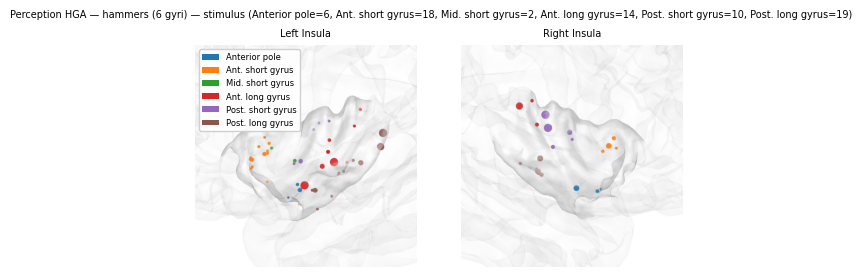

In [24]:
import re

HAMMERS_GYRI = [
    'anterior pole',
    'anterior short gyrus',
    'middle short gyrus',
    'anterior long gyrus',
    'posterior short gyrus',
    'posterior long gyrus',
]
HAMMERS_GYRUS_LABELS = {
    'anterior pole': 'Anterior pole',
    'anterior short gyrus': 'Ant. short gyrus',
    'middle short gyrus': 'Mid. short gyrus',
    'anterior long gyrus': 'Ant. long gyrus',
    'posterior short gyrus': 'Post. short gyrus',
    'posterior long gyrus': 'Post. long gyrus',
}
HAMMERS_GYRUS_COLORS = dict(
    zip(HAMMERS_GYRI, sns.color_palette('tab10', len(HAMMERS_GYRI)))
)


def hammers_insula_gyrus(label):
    """Parse Hammers insula gyrus name from label, e.g. 'insula anterior pole L'."""
    if pd.isna(label):
        return pd.NA
    text = str(label).strip()
    if not text or text == '0':
        return pd.NA
    match = re.search(r'insula\s+(.+?)\s+[LR]$', text, flags=re.I)
    if match:
        return match.group(1).strip().lower()
    return pd.NA


def attach_hammers_gyrus(spatial_df):
    out = spatial_df.copy()
    out['hammers_gyrus'] = out['label'].map(hammers_insula_gyrus)
    return out


def _add_electrodes_colors(brain, coords, hga_vals, colors, tree, pial_coords):
    _, indices = tree.query(coords)
    coords_proj = pial_coords[indices]
    sizes, _, _ = _hga_to_size(hga_vals)
    for i, pt in enumerate(coords_proj):
        color = colors[i]
        if color is None or (isinstance(color, float) and np.isnan(color)):
            continue
        cloud = pv.PolyData(pt.reshape(1, 3))
        brain._renderer.plotter.add_mesh(
            cloud, render_points_as_spheres=True,
            point_size=sizes[i], color=color, lighting=False,
        )


def plot_hammers_gyrus_spatial(spatial_df, *, title, save_path=None):
    """Top-down LH/RH insula panel colored by Hammers gyrus (6 partitions)."""
    plot_df = spatial_df[spatial_df['hammers_gyrus'].isin(HAMMERS_GYRI)].copy()
    if plot_df.empty:
        print(f'Skip plot (no Hammers gyrus electrodes): {title}')
        return

    n_skip = len(spatial_df) - len(plot_df)
    if n_skip:
        print(f'{title}: skipping {n_skip} electrodes without a Hammers gyrus label')

    cord = plot_df[['x', 'y', 'z']].values
    hga_values = plot_df['HGA'].values
    colors = plot_df['hammers_gyrus'].map(HAMMERS_GYRUS_COLORS).tolist()
    mask_lh = cord[:, 0] < 0
    mask_rh = cord[:, 0] > 0

    lh_brain = _make_insula_brain('lh')
    rh_brain = _make_insula_brain('rh')
    if mask_lh.any():
        _add_electrodes_colors(
            lh_brain, cord[mask_lh], hga_values[mask_lh], np.array(colors)[mask_lh],
            lh_tree, lh_pial_coords,
        )
    if mask_rh.any():
        _add_electrodes_colors(
            rh_brain, cord[mask_rh], hga_values[mask_rh], np.array(colors)[mask_rh],
            rh_tree, rh_pial_coords,
        )

    lh_brain.show_view(azimuth=180, elevation=90, distance=180, focalpoint=lh_center)
    rh_brain.show_view(azimuth=0, elevation=90, distance=180, focalpoint=rh_center)

    fig, axes = plt.subplots(1, 2, figsize=(16 * cm, 8 * cm))
    axes[0].imshow(lh_brain.screenshot(mode='rgb'))
    axes[0].axis('off')
    axes[0].set_title('Left Insula', fontsize=fontsize)
    axes[1].imshow(rh_brain.screenshot(mode='rgb'))
    axes[1].axis('off')
    axes[1].set_title('Right Insula', fontsize=fontsize)

    present = [g for g in HAMMERS_GYRI if g in set(plot_df['hammers_gyrus'])]
    axes[0].legend(
        handles=[
            Patch(facecolor=HAMMERS_GYRUS_COLORS[g], label=HAMMERS_GYRUS_LABELS[g])
            for g in present
        ],
        loc='upper left', fontsize=fontsize - 1, framealpha=0.9,
    )

    counts = plot_df['hammers_gyrus'].value_counts().reindex(HAMMERS_GYRI).fillna(0).astype(int)
    count_str = ', '.join(f'{HAMMERS_GYRUS_LABELS[g]}={counts[g]}' for g in present)
    plt.suptitle(f'{title} — {phase} ({count_str})', fontsize=fontsize)
    lh_brain.close()
    rh_brain.close()
    plt.subplots_adjust(bottom=0.15)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


spatial_hammers_gyri = attach_hammers_gyrus(spatial_hammers)
print('Hammers gyrus counts (spatial window):')
print(spatial_hammers_gyri['hammers_gyrus'].value_counts().reindex(HAMMERS_GYRI).fillna(0).astype(int))

plot_hammers_gyrus_spatial(
    spatial_hammers_gyri,
    title='Perception HGA — hammers (6 gyri)',
    # save_path=f'../img/fig2/fig2v1_insula_spatial_hammers_gyri_{phase}.svg',
)

## Temporal — AIC vs PIC (aparc vs hammers)

Grand-average HGA time courses (Repeat / sound), four phase panels per atlas.
aparc uses Y + Destrieux label (`classify_insula_row`); hammers uses pure `roi` → AIC / PIC.


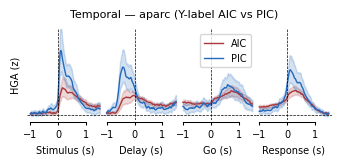

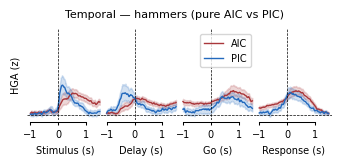

In [25]:
def classify_insula_row(row, y_threshold=0):
    """Classify aparc Insula electrodes into AIC or PIC."""
    roi = row.get('roi')
    if roi not in ('Insula', 'INS'):
        return roi
    label = row['label']
    y_coord = row['y']
    if ('G_insular_short' in label or
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    if ('G_Ins_lg_and_S_cent_ins' in label or
        ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
        ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    return roi


def _channel_sub_roi(hgas, atlas):
    meta = hgas[['channel', 'roi', 'label', 'y']].drop_duplicates('channel').copy()
    if atlas in ('aparc', 'aparc2009s'):
        meta['sub_roi'] = meta.apply(classify_insula_row, axis=1, y_threshold=0)
    else:
        meta['sub_roi'] = meta['roi'].where(meta['roi'].isin(['AIC', 'PIC']))
    return meta[['channel', 'sub_roi']]


def plot_aic_pic_timeseries(hgas, atlas, title, save_path=None):
    rois = ['AIC', 'PIC']
    colors = [red, blue]
    phases = ['stimulus', 'delay', 'go', 'response']

    sub_roi = _channel_sub_roi(hgas, atlas)
    df = hgas.merge(sub_roi, on='channel', how='left')
    subset = df[
        (df.description == 'Repeat')
        & (df.modality == 'sound')
        & (df.subject != 'D0121')
        & (df.sub_roi.isin(rois))
    ]

    fig, axes = plt.subplots(nrows=1, ncols=len(phases), figsize=(2.5 * len(phases) * cm, 3 * cm))
    plt.subplots_adjust(wspace=0)

    for ax, phase_name in zip(axes, phases):
        legend = ax == axes[-2]
        sns.lineplot(
            data=subset[subset.phase == phase_name],
            x='time', y='value', hue='sub_roi', hue_order=rois,
            ax=ax, palette=colors, legend=legend, lw=1,
        )
        ax.set_xlabel(f'{phase_name.capitalize()} (s)', fontsize=7)

    for ax in axes:
        ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
        ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
        ax.tick_params(labelsize=7, width=0.75, length=2, which='both')
        plt.setp(ax.spines.values(), linewidth=0.75)
        sns.despine(ax=ax, offset=1, trim=True)
        if ax == axes[-2] and ax.get_legend() is not None:
            ax.legend(title='', fontsize=7)
        else:
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()
        ax.set_yticklabels([])
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)
        ax.set_ylim(-0.1, 1.5)
        if ax == axes[0]:
            ax.set_ylabel('HGA (z)', fontsize=7)
        else:
            ax.set_ylabel('', fontsize=7)

    plt.suptitle(title, fontsize=8, y=1.05)
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()


plot_aic_pic_timeseries(
    HGAs_aparc.loc[insula_mask(HGAs_aparc, 'aparc')],
    atlas='aparc',
    title='Temporal — aparc (Y-label AIC vs PIC)',
)

plot_aic_pic_timeseries(
    HGAs_hammers.loc[insula_mask(HGAs_hammers, 'hammers')],
    atlas='hammers',
    title='Temporal — hammers (pure AIC vs PIC)',
)
